In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, classification_report, ConfusionMatrixDisplay

In [99]:
df= pd.read_csv("heart.csv")

In [100]:
df.sample(3)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
224,54,1,0,110,239,0,1,126,1,2.8,1,1,3,0
187,54,1,0,124,266,0,0,109,1,2.2,1,1,3,0
108,50,0,1,120,244,0,1,162,0,1.1,2,0,2,1


In [101]:
X= df.drop("target", axis=1)
y= df["target"]

# Train Test Split

In [102]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size= 0.2, random_state= 42)

# Model Selection

In [103]:
clf1= LogisticRegression()
clf2= DecisionTreeClassifier()
clf1.fit(X_train, y_train)
clf2.fit(X_train, y_train)
y_pred1= clf1.predict(X_test)
y_pred2= clf2.predict(X_test)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Confusion Matrix

In [104]:
print("Confusion Matrix of Logistic Regression:\n\n", confusion_matrix(y_test, y_pred1))
print("\n\nConfusion Matrix of Decision Tree:\n\n", confusion_matrix(y_test, y_pred2))

Confusion Matrix of Logistic Regression:

 [[25  4]
 [ 3 29]]


Confusion Matrix of Decision Tree:

 [[26  3]
 [ 8 24]]


# Type 1 and Type 2 Error

In [105]:
cm= confusion_matrix(y_test, y_pred1)
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("Type I Error (FP) of Logistic Regression:", FP)
print("Type II Error (FN) of Logistic Regression:", FN)

Type I Error (FP) of Logistic Regression: 4
Type II Error (FN) of Logistic Regression: 3


# Accuracy Score

In [106]:
print("Accuracy of Logistic Regression: ", accuracy_score(y_test, y_pred1))
print("Accuracy of Decision Tree: ", accuracy_score(y_test, y_pred2))

Accuracy of Logistic Regression:  0.8852459016393442
Accuracy of Decision Tree:  0.819672131147541


##### Similarly we can calculate recall_score, precision_score, f1_score individually

# Classification Report

In [107]:
print("Classification Report of Logistic Regression:\n\n ", classification_report(y_test, y_pred1))
print("\n\nClassification Report of Decision Tree:\n\n ", classification_report(y_test, y_pred2))

Classification Report of Logistic Regression:

                precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



Classification Report of Decision Tree:

                precision    recall  f1-score   support

           0       0.76      0.90      0.83        29
           1       0.89      0.75      0.81        32

    accuracy                           0.82        61
   macro avg       0.83      0.82      0.82        61
weighted avg       0.83      0.82      0.82        61



# Visualization of Confusion Matrix

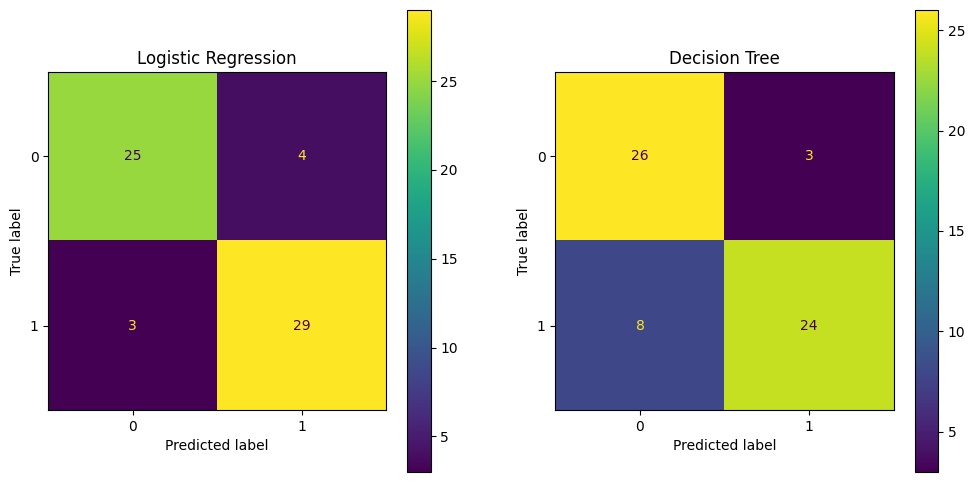

In [108]:
fig, ax= plt.subplots(ncols=2, figsize=(12,6))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred1, ax= ax[0])
ax[0].set_title("Logistic Regression")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred2, ax=ax[1])
ax[1].set_title("Decision Tree")
plt.show()